In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, sem, ttest_1samp
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.optimize import curve_fit
from my_fun import fig_size, add_star_between, get_experiment, filter_drug_sessions, compute_psych_curve, save_notebook_files
from pathlib import Path
from glue_sessions.glue_sessions import glue_animals, glue_groups
from glmhmm import *
import ast

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [5]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

# Model comparison

## Load null model (Bernoulli coin-flip)

In [4]:
# df_1s_null = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=1, covariates=['bias'], drug=None, save=True)
df_1s_null = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_null')
ll_null = df_1s_null['LogLikelihood'].unique()
n_trials = df_1s_null.groupby('Subject').size()

In [5]:
figsize = fig_size(n_cols=3)
figsize = (figsize[0], figsize[1] * 2)

## 1 covariate (stimulus)

In [5]:
# df_1s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_1cov')
# df_2s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/2s_1cov')
# # df_3s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/3s_1cov')
# df_4s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/4s_1cov')
# df_5s_1cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/5s_1cov')
#
# figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[1]*2)
# plt.figure(figsize=figsize, constrained_layout=True)
#
# ll_1 = df_1s_1cov['LogLikelihood'].unique()
# ll_2 = df_2s_1cov['LogLikelihood'].unique()
# # ll_3 = df_3s_1cov['LogLikelihood'].unique()
# ll_4 = df_4s_1cov['LogLikelihood'].unique()
# ll_5 = df_5s_1cov['LogLikelihood'].unique()
#
# n_trials_1 = df_1s_1cov.groupby('Subject').size()
# n_trials_2 = df_2s_1cov.groupby('Subject').size()
# # n_trials_3 = df_3s_1cov.groupby('Subject').size()
# n_trials_4 = df_4s_1cov.groupby('Subject').size()
# n_trials_5 = df_5s_1cov.groupby('Subject').size()
#
# ll_1 = plot_ll(ll_1, n_trials_1, to_bits=True, positions=[1])
# ll_2 = plot_ll(ll_2, n_trials_2, to_bits=True, positions=[2])
# # ll_3 = plot_ll(ll_3, n_trials_3, to_bits=True, positions=[3])
# ll_4 = plot_ll(ll_4, n_trials_4, to_bits=True, positions=[4])
# ll_5 = plot_ll(ll_5, n_trials_5, to_bits=True, positions=[5])
#
# ll_1 = np.array(ll_1)
# ll_2 = np.array(ll_2)
# ll_3 = np.array(ll_3)
# ll_4 = np.array(ll_4)
# ll_5 = np.array(ll_5)
#
# inliers_1 = iqr_inliers(ll_1)
# inliers_2 = iqr_inliers(ll_2)
# inliers_3 = iqr_inliers(ll_3)
# inliers_4 = iqr_inliers(ll_4)
# inliers_5 = iqr_inliers(ll_5)
#
# # for y0, y1 in zip(ll0, ll1):
# #     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
# mask = inliers_1 & inliers_2 & inliers_3 & inliers_4 & inliers_5
# for y1, y2 in zip(ll_1[mask], ll_2[mask]):
#     plt.plot([1, 2], [y1, y2], color='k', alpha=0.1)
# for y2, y3 in zip(ll_2[mask], ll_3[mask]):
#     plt.plot([2, 3], [y2, y3], color='k', alpha=0.1)
# for y3, y4 in zip(ll_3[mask], ll_4[mask]):
#     plt.plot([3, 4], [y3, y4], color='k', alpha=0.1)
# for y4, y5 in zip(ll_4[mask], ll_5[mask]):
#     plt.plot([4, 5], [y4, y5], color='k', alpha=0.1)
#
# # Paired t-test between states (not needed because sums to 1)
# t_stat, p_val = ttest_rel(ll_1, ll_2)
# print(f't = {t_stat:.3f}, p = {p_val:.3f}')
# add_star_between(p_val, 1, 2)
# t_stat, p_val = ttest_rel(ll_2, ll_3)
# print(f't = {t_stat:.3f}, p = {p_val:.3f}')
# add_star_between(p_val, 2, 3)
# t_stat, p_val = ttest_rel(ll_3, ll_4)
# print(f't = {t_stat:.3f}, p = {p_val:.3f}')
# add_star_between(p_val, 3, 4)
# t_stat, p_val = ttest_rel(ll_4, ll_5)
# print(f't = {t_stat:.3f}, p = {p_val:.3f}')
# add_star_between(p_val, 4, 5)
#
# plt.xticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'])
# plt.xlabel('N states')
# plt.title('2 Covariates\n(stim. and bias)')
# sns.despine()
#
# ll_1_cov_means = [np.mean(ll_1), np.mean(ll_2), np.mean(ll_3), np.mean(ll_4), np.mean(ll_5)]

## 2 covariates (stim and bias)

Loading results of model with 1 states and 2 covariates
0.30 ± 0.32 LL (bits/trial)
Loading results of model with 2 states and 2 covariates
0.39 ± 0.33 LL (bits/trial)
Loading results of model with 3 states and 2 covariates
0.43 ± 0.35 LL (bits/trial)
Loading results of model with 4 states and 2 covariates
0.45 ± 0.35 LL (bits/trial)
Loading results of model with 5 states and 2 covariates
0.46 ± 0.37 LL (bits/trial)
t = -9.531, p = 0.000
t = -8.759, p = 0.000
t = -6.533, p = 0.000
t = -5.524, p = 0.000


(0, 1)

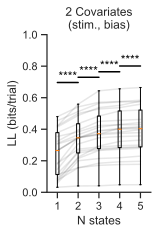

In [70]:
plt.figure(figsize=figsize, constrained_layout=True)
lls_2cov = plot_model_comparison(n_cov=2, ll_null=ll_null, fit=False)
plt.ylim(0, 1)

Loading results of model with 1 states and 2 covariates
Loading results of model with 2 states and 2 covariates
Loading results of model with 3 states and 2 covariates
Loading results of model with 4 states and 2 covariates
Loading results of model with 5 states and 2 covariates


Text(0.5, 1.0, '')

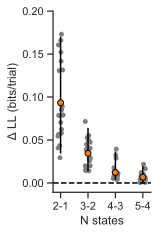

In [64]:
plt.figure(figsize=figsize, constrained_layout=True)
diffs_2cov = plot_model_comparison_diffs(n_cov=2, ll_null=None, fit=False)
plt.ylim(None, 0.2)
plt.title('')

º## 3 covariates  (stimulus, bias, and action trace)

Loading results of model with 1 states and 3 covariates
0.38 ± 0.33 LL (bits/trial)
Loading results of model with 2 states and 3 covariates
0.44 ± 0.35 LL (bits/trial)
Loading results of model with 3 states and 3 covariates
0.45 ± 0.37 LL (bits/trial)
Loading results of model with 4 states and 3 covariates
0.47 ± 0.37 LL (bits/trial)
Loading results of model with 5 states and 3 covariates
0.47 ± 0.37 LL (bits/trial)
t = -10.721, p = 0.000
t = -4.540, p = 0.000
t = -5.328, p = 0.000
t = -4.238, p = 0.000


(0, 1)

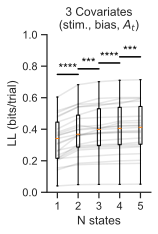

In [71]:
plt.figure(figsize=figsize, constrained_layout=True)
lls_3cov = plot_model_comparison(n_cov=3, ll_null=ll_null, fit=False)
plt.ylim(0, 1)

Loading results of model with 1 states and 3 covariates
Loading results of model with 2 states and 3 covariates
Loading results of model with 3 states and 3 covariates
Loading results of model with 4 states and 3 covariates
Loading results of model with 5 states and 3 covariates


Text(0.5, 1.0, '')

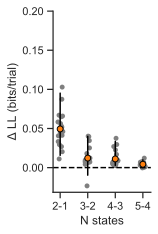

In [66]:
plt.figure(figsize=figsize, constrained_layout=True)
diffs_3cov = plot_model_comparison_diffs(n_cov=3, ll_null=None, fit=False)
plt.ylim(None, 0.2)
plt.title('')

## 4 covariates  (stimulus, bias, At- and At+)

Loading results of model with 1 states and 4 covariates
0.39 ± 0.33 LL (bits/trial)
Loading results of model with 2 states and 4 covariates
0.44 ± 0.35 LL (bits/trial)
Loading results of model with 3 states and 4 covariates
0.46 ± 0.37 LL (bits/trial)
Loading results of model with 4 states and 4 covariates
0.47 ± 0.37 LL (bits/trial)
Loading results of model with 5 states and 4 covariates
0.47 ± 0.38 LL (bits/trial)
t = -11.649, p = 0.000
t = -4.861, p = 0.000
t = -5.843, p = 0.000
t = -3.614, p = 0.001


(0, 1)

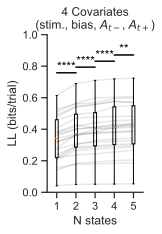

In [72]:
plt.figure(figsize=figsize, constrained_layout=True)
lls_4cov = plot_model_comparison(n_cov=4, ll_null=ll_null, fit=False)
plt.ylim(0, 1)

Loading results of model with 1 states and 4 covariates
Loading results of model with 2 states and 4 covariates
Loading results of model with 3 states and 4 covariates
Loading results of model with 4 states and 4 covariates
Loading results of model with 5 states and 4 covariates


Text(0.5, 1.0, '')

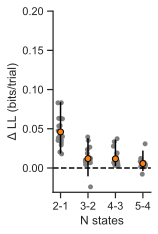

In [68]:
plt.figure(figsize=figsize, constrained_layout=True)
diffs_4cov = plot_model_comparison_diffs(n_cov=4, ll_null=None, fit=False)
plt.ylim(None, 0.2)
plt.title('')

## LL per state

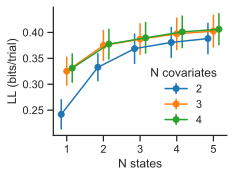

In [98]:
# Remove outliers based on IQR
inliers_2cov = [iqr_inliers(ll) for ll in lls_2cov]
inliers_3cov = [iqr_inliers(ll) for ll in lls_3cov]
inliers_4cov = [iqr_inliers(ll) for ll in lls_4cov]
lls_2cov = [ll[inliers] for ll, inliers in zip(lls_2cov, inliers_2cov)]
lls_3cov = [ll[inliers] for ll, inliers in zip(lls_3cov, inliers_3cov)]
lls_4cov = [ll[inliers] for ll, inliers in zip(lls_4cov, inliers_4cov)]

# Compute mean and sem LL per state (across subjects) for each model
means_2cov = [ll.mean() for ll in lls_2cov]
means_3cov = [ll.mean() for ll in lls_3cov]
means_4cov = [ll.mean() for ll in lls_4cov]
sems_2cov = [sem(ll) for ll in lls_2cov]
sems_3cov = [sem(ll) for ll in lls_3cov]
sems_4cov = [sem(ll) for ll in lls_4cov]

figsize = fig_size(n_cols=2)
plt.figure(figsize=figsize, constrained_layout=True)

# Plot all curves in one figure
x = np.arange(5)
jitter = 0.15
plt.errorbar(x - jitter, means_2cov, yerr=sems_2cov, marker='o', label='2')
plt.errorbar(x, means_3cov, yerr=sems_3cov, marker='o', label='3')
plt.errorbar(x + jitter, means_4cov, yerr=sems_4cov, marker='o', label='4')

# plt.plot(means_2cov, marker='o', label='2')
# plt.fill_between(range(5), np.array(means_2cov)-np.array(sems_2cov),
#                  np.array(means_2cov)+np.array(sems_2cov), alpha=0.1)
# plt.plot(means_3cov, marker='o', label='3')
# plt.fill_between(range(5), np.array(means_3cov)-np.array(sems_3cov),
#                  np.array(means_3cov)+np.array(sems_3cov), alpha=0.1)
# plt.plot(means_4cov, marker='o', label='4')
# plt.fill_between(range(5), np.array(means_4cov)-np.array(sems_4cov),
#                  np.array(means_4cov)+np.array(sems_4cov), alpha=0.1)

plt.xticks(range(5), ['1', '2', '3', '4', '5'])  # N states
plt.xlabel('N states')
plt.ylabel('LL (bits/trial)')
# plt.title('Model comparison')
plt.legend(title='N covariates', frameon=False)
sns.despine()

From the model comparison, the best models are 2 states with 3 covariates and 3 states with 2 covariates. Let's compare them directly.

# Final match: 2 states and 3 covariates VS 3 states and 2 covariates

In [4]:
df1 = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session=f'glmhmm/TEST/2s_3cov')
df2 = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session=f'glmhmm/TEST/3s_2cov')

## Log likelihood

0.44 ± 0.35 LL (bits/trial)
0.43 ± 0.35 LL (bits/trial)
t = 2.200, p = 0.038


(-0.05, 0.05)

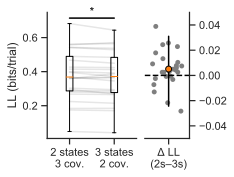

In [84]:
ll_2s_3cov = df1['LogLikelihood'].unique()
ll_3s_2cov = df2['LogLikelihood'].unique()
n_trials = df1.groupby('Subject').size()
n_trials = df2.groupby('Subject').size()

figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[1] * 2)
fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, gridspec_kw={'width_ratios': [2, 1]})
ax_left, ax_right = axes
plt.sca(ax_left)
# plt.figure(figsize=figsize, constrained_layout=True)

ll_2s_3cov = plot_ll(ll_2s_3cov, n_trials, ll_null, to_bits=True, positions=[1])
ll_3s_2cov = plot_ll(ll_3s_2cov, n_trials, ll_null, to_bits=True, positions=[2])
plt.xticks([1, 2] , ['2 states\n3 cov.', '3 states\n2 cov.'])
plt.xlabel('')

ll_2s_3cov = np.array(ll_2s_3cov)
ll_3s_2cov = np.array(ll_3s_2cov)
lls = [ll_2s_3cov, ll_3s_2cov]

inliers_2s_3cov = iqr_inliers(ll_2s_3cov)
inliers_3s_2cov = iqr_inliers(ll_3s_2cov)
inliers = [inliers_2s_3cov, inliers_3s_2cov]
mask = np.logical_and.reduce(inliers)  # Reuse for later

for i in range(len(lls) - 1):
    for y_prev, y_next in zip(lls[i][mask], lls[i + 1][mask]):
        plt.plot([i + 1, i + 2], [y_prev, y_next], color='k', alpha=0.1)
    t_stat, p_val = ttest_rel(lls[i][mask], lls[i + 1][mask])
    print(f't = {t_stat:.3f}, p = {p_val:.3f}')
    add_star_between(p_val, i + 1, i + 2)

# Compute paired differences
diff =  ll_2s_3cov - ll_3s_2cov
plt.sca(ax_right)
sns.stripplot(y=diff, color='tab:gray', ax=ax_right, zorder=1)
mean_diff = diff.mean()
ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
plt.plot([0, 0], [ci_low, ci_high], color='k', zorder=2)
plt.scatter(0, mean_diff, facecolor='tab:orange', edgecolor='k', zorder=3)
plt.axhline(0, color='k', ls='--')

plt.xticks([0], ['Δ LL\n(2s–3s)'])
# plt.ylabel('Δ LL (bits/trial)')
ax_right.yaxis.tick_right()
ax_right.yaxis.set_label_position('right')
ax_right.spines['top'].set_visible(False)
ax_right.spines['left'].set_visible(False)
ax_right.spines['right'].set_visible(True)
ax_right.set_ylim(-0.05, 0.05)

## Weights

Kept 20 / 25 subjects after column-wise IQR filtering
Kept 17 / 25 subjects after column-wise IQR filtering


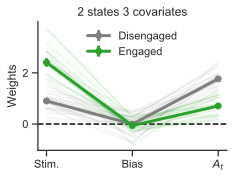

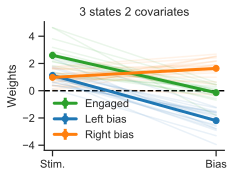

In [10]:
plot_GLMHMM_kernel(df1)
plot_GLMHMM_kernel(df2)

Find outliers IDs

In [112]:
# # Find outliers based on weights
# weights = get_weights(df1)
# flattened = weights.reshape(weights.shape[0], -1)  # Flatten each 2D array to 1D
# unique_flat = np.unique(flattened, axis=0)  # Keep only unique arrays
# weights = unique_flat.reshape(-1, weights.shape[1], weights.shape[2])  # Reshape back to original 2D shape per array
# mask = remove_outliers(weights)
# subjects = df1.Subject.unique()
# outliers_id = subjects[~mask]
# outliers_exp = [df1[df1.Subject == id].Experiment.unique()[0] for id in outliers_id]
#
# from psychometric_curves import plot_pc
# figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[0])
# for id, exp in zip(outliers_id, outliers_exp):
#     plot_pc(experiment=exp, animal=str(id), kind='prob_right', drug=None, save=False, figsize=figsize)

In [111]:
# # Find outliers based on weights
#
# weights = get_weights(df2)
# flattened = weights.reshape(weights.shape[0], -1)  # Flatten each 2D array to 1D
# unique_flat = np.unique(flattened, axis=0)  # Keep only unique arrays
# weights = unique_flat.reshape(-1, weights.shape[1], weights.shape[2])  # Reshape back to original 2D shape per array
# mask = remove_outliers(weights)
# subjects = df2.Subject.unique()
# outliers_id = subjects[~mask]
# outliers_exp = [df2[df2.Subject == id].Experiment.unique()[0] for id in outliers_id]
#
# from psychometric_curves import plot_pc
# figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[0])
# for id, exp in zip(outliers_id, outliers_exp):
#     plot_pc(experiment=exp, animal=str(id), kind='prob_right', drug=None, save=False, figsize=figsize)

Kept 20 / 25 subjects after column-wise IQR filtering
Covariate 0: t=11.354, p=0.0000
Covariate 1: t=-1.081, p=0.2932
Covariate 2: t=-8.488, p=0.0000


Text(0.5, 1, '2 states 3 covariates')

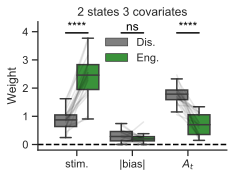

In [157]:
data = results_2_df(df1)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data, figsize=figsize, loc='upper center',  bbox_to_anchor=(0.5, 0.95))
plt.title('2 states 3 covariates')

Kept 17 / 25 subjects after column-wise IQR filtering
Covariate 0, Eng-Lbias: t=6.485, p=0.0000
Covariate 0, Eng-Rbias: t=8.038, p=0.0000
Covariate 0, Lbias-Rbias: t=0.824, p=0.4222
Covariate 1, Eng-Lbias: t=-8.969, p=0.0000
Covariate 1, Eng-Rbias: t=-5.914, p=0.0000
Covariate 1, Lbias-Rbias: t=1.872, p=0.0796


Text(0.5, 1, '3 states 2 covariates')

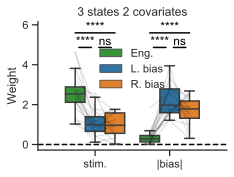

In [159]:
data = results_2_df(df2)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.865))
plt.title('3 states 2 covariates')

### Stimulus weights between engaged states

Kept 20 / 25 subjects after column-wise IQR filtering
Kept 17 / 25 subjects after column-wise IQR filtering
t = -2.007, p = 0.056


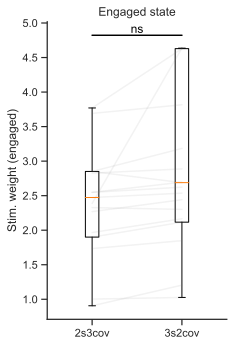

In [16]:
weights_1 = get_weights(df1)
weights_2 = get_weights(df2)
mask_1 = remove_outliers(weights_1)
mask_2 = remove_outliers(weights_2)
paired_mask = mask_1 & mask_2
# weights_1 = weights_1[paired_mask]
# weights_2 = weights_2[paired_mask]

# Extract stim weight in engaged state
stim_w_1 = weights_1[:, 1, 0]
stim_w_2 = weights_2[:, 0, 0]

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1] * 2)
plt.figure(figsize=figsize, constrained_layout=True)
plt.boxplot([stim_w_1, stim_w_2], labels=['2s3cov', '3s2cov'], showfliers=False)
# Paired lines
for x1, x2 in zip(stim_w_1[paired_mask], stim_w_2[paired_mask]):
    plt.plot([1, 2], [x1, x2], color='gray', alpha=0.1)
t_stat, p_val = ttest_rel(stim_w_1, stim_w_2)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 1, 2)
plt.ylabel('Stim. weight (engaged)')
plt.title('Engaged state')
sns.despine()

## P(engaged)

### Mean

In [17]:
def plot_p_engaged(df):

    figsize = fig_size(n_cols=1)
    figsize = (figsize[0], figsize[1] * 0.5)
    plt.figure(figsize=figsize, constrained_layout=True)

    n_states = df.Nstates.unique()[0]
    input_dim = df.InputDimensions.unique()[0]

    # Plot each state's mean kernel
    if n_states == 2 and input_dim == 3:
        p_engaged = 'p1'
        color = 'tab:green'
    elif n_states == 3 and input_dim == 2:
        p_engaged = 'p0'
        color = 'tab:red'
    else:
        raise ValueError('Unsupported combination of states and covariates for p(engaged) plotting.')

    # Reindex trial number (discontinuous after removing misses)
    trial_reindex = df.groupby(['Subject', 'Session']).cumcount()
    df['TrialReindex'] = trial_reindex

    # Mean P(engaged) across subjects
    mean_p_engaged = (df.groupby(['Subject', 'TrialReindex'], as_index=False)[p_engaged].mean())
    mean_trials = df1.groupby('Session').size().mean() * 2

    # Individual subjects
    for subject, g in mean_p_engaged.groupby('Subject'):
        plt.plot(g['TrialReindex'], g[p_engaged], color='tab:gray', alpha=0.1)

    # Mean ± SEM across subjects
    pop = (mean_p_engaged.groupby('TrialReindex')[p_engaged].agg(['mean', 'sem']).reset_index())

    # Plot
    plt.axhline(y=0.5, color='k', ls='--')
    plt.plot(pop['TrialReindex'], pop['mean'], color=color)
    band = pop['mean'] - pop['sem'], pop['mean'] + pop['sem']
    plt.fill_between(pop['TrialReindex'], band[0], band[1], color=color, edgecolor='none', alpha=0.25)
    plt.xlim(0, mean_trials)
    plt.xlabel('Trial')
    plt.ylabel(r'Mean $p$(engaged)')
    plt.title(f'{n_states} states {input_dim} covariates')
    sns.despine()

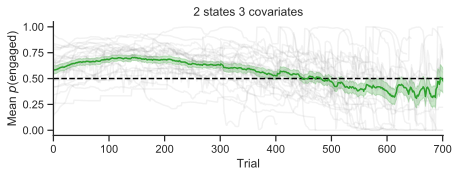

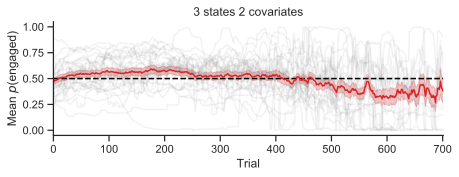

In [18]:
plot_p_engaged(df1)
plot_p_engaged(df2)

In [19]:
def plot_p_engaged_dist(df1, df2):

    figsize = fig_size(n_cols=2)
    plt.figure(figsize=figsize, constrained_layout=True)

    n_states = df1.Nstates.unique()[0]
    input_dim = df1.InputDimensions.unique()[0]

    # Plot each state's mean kernel
    if n_states == 2 and input_dim == 3:
        p_engaged = 'p1'
    elif n_states == 3 and input_dim == 2:
        p_engaged = 'p0'
    else:
        raise ValueError('Unsupported combination of states and covariates for p(engaged) plotting.')

    n_bins = int(100/5)  # 5% steps
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Model 1
    hists_1 = []
    for _, g in df1.groupby('Subject'):
        h, _ = np.histogram(g[p_engaged], bins=bins, density=True)
        hists_1.append(h)
    hists_1 = np.vstack(hists_1)
    mean_1 = hists_1.mean(axis=0)
    sem_1 = sem(hists_1, axis=0)

    # Model 2
    hists_2 = []
    for _, g in df2.groupby('Subject'):
        h, _ = np.histogram(g['p0'], bins=bins, density=True)
        hists_2.append(h)
    hists_2 = np.vstack(hists_2)
    mean_2 = hists_2.mean(axis=0)
    sem_2 = sem(hists_2, axis=0)

    # Extend mean values to match bin edges
    mean_1 = np.append(mean_1, mean_1[-1])
    mean_2 = np.append(mean_2, mean_2[-1])
    plt.step(bins, mean_1, where='post', color='tab:green', label='2s 3cov')
    plt.step(bins, mean_2, where='post', color='tab:red', label='3s 2cov')

    plt.xlabel(r'$p$(engaged)')
    plt.ylabel('Density')
    plt.ylim(0, None)
    plt.legend(frameon=False)
    sns.despine()

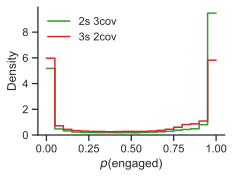

In [20]:
plot_p_engaged_dist(df1, df2)

### Single sessions

In [21]:
def plot_subject_model_comparison(df1, df2, subject=333, n_sessions=3):
    """
    df1: first model dataframe (e.g., 2s/3cov)
    df2: second model dataframe (e.g., 3s/2cov)
    subject: subject ID to plot
    n_sessions: number of sessions to overlay
    """

    # Filter by subject
    df1 = df1[df1['Subject'] == subject].copy()
    df2 = df2[df2['Subject'] == subject].copy()

    # Get sessions
    # sessions = sorted(df1['Session'].unique())[:n_sessions]  # First n_sessions
    # Pick n_sessions randomly
    mean_trials = df1.groupby('Session').size().mean()  # Mean number of trials per session
    # sessions = df1['Session'].unique()
    sessions = [s for s, n in df1.groupby('Session').size().items() if n >= mean_trials]  # Keep only sessions with enough trials
    sessions = np.random.choice(sessions, size=min(n_sessions, len(sessions)), replace=False)
    sessions = sorted(sessions)

    figsize = fig_size(n_cols=1)
    figsize = (figsize[0], figsize[1] * 0.5)
    plt.figure(figsize=figsize, constrained_layout=True)

    # Color maps for gradients. https://matplotlib.org/stable/users/explain/colors/colormaps.html
    tab20c = cm.get_cmap('tab20c')
    green_colors = [tab20c(8 + i) for i in range(n_sessions)]  # Greens for 2s model: indices 8-12
    red_colors = [tab20c(4 + i) for i in range(n_sessions)]  # Reds for 3s model: indices 12-16

    labels = ['2s_3cov', '3s_2cov']

    for i, sess in enumerate(sessions):
        # df1: 2s/3cov
        d1 = df1[df1['Session'] == sess].copy()
        d1['TrialReindex'] = d1.groupby(['Subject', 'Session']).cumcount()
        plt.plot(d1['TrialReindex'], d1['p1'], color=green_colors[i], label=labels[0] if i==0 else "")

        # df2: 3s/2cov
        d2 = df2[df2['Session'] == sess].copy()
        d2['TrialReindex'] = d2.groupby(['Subject', 'Session']).cumcount()
        plt.plot(d2['TrialReindex'], d2['p0'], color=red_colors[i], label=labels[1] if i==0 else "")

    plt.axhline(0.5, color='k', ls='--')
    plt.xlim(None, mean_trials)
    plt.xlabel('Trial')
    plt.ylabel(r'$p$(engaged)')
    plt.legend()
    sns.despine()

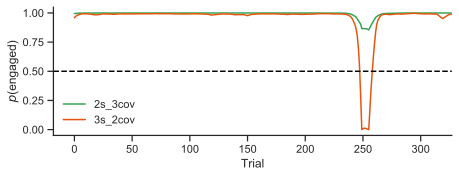

In [22]:
plot_subject_model_comparison(df1, df2, subject=333, n_sessions=1)

### Comparison

t = 4.398, p = 0.000


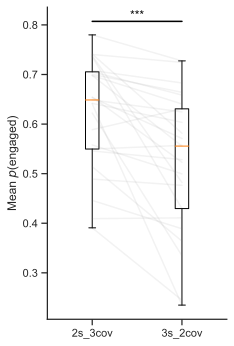

In [23]:
# Mean p(engaged) per mouse
df1_mouse = df1.groupby('Subject')['p1'].mean()
df2_mouse = df2.groupby('Subject')['p0'].mean()

subjects = df1_mouse.index
data = [df1_mouse.values, df2_mouse.values]

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1] * 2)
plt.figure(figsize=figsize, constrained_layout=True)
plt.boxplot(data, positions=[1, 2])

t_stat, p_val = ttest_rel(df1_mouse, df2_mouse)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 1, 2)

# Paired lines connecting the same mouse
for i in range(len(subjects)):
    plt.plot([1,2], [df1_mouse.values[i], df2_mouse.values[i]],
            color='tab:gray', alpha=0.1)

plt.xticks([1, 2], ['2s_3cov', '3s_2cov'])
plt.ylabel(r'Mean $p$(engaged)')
sns.despine()

Both models have different baselines, and they need to be corrected. Substract 0.5 and 0.3 from every datapoint in each model.

## Psychometric curves

### Stimulus

In [24]:
def plot_pc_across_batches(experiments=None, kind='prob_right', model='2s_3cov', state_labels=['Disengaged', 'Engaged'], colors=['tab:gray', 'tab:green'], **kwargs):

    if experiments is None:
        experiments = ['2AFC_2', '2AFC_3', '2AFC_4']
    all_animals = main(experiments)

    plt.figure(constrained_layout=True, **kwargs)
    n_points = 100

    for _ in range(len(state_labels)):

        fit = []
        fit_error = []
        params = []
        xdata = []
        ydata = []
        trials = 0
        n_animals = 0

        for experiment in experiments:

            # Get the path to the data
            folder_in = Path.home() / 'PycharmProjects' / 'glmhmm' / 'TEST' / model / experiment
            animals = all_animals[experiment]

            for i in range(len(animals)):
                df = pd.read_csv(Path(folder_in / animals[i]).with_suffix('.csv'))
                df = df[df.P > 0]  # Only those sessions with ilds
                df = df[df.StateLabel == state_labels[_]]
                ilds = np.sort(df.ILD.unique())

                if kind == 'prob_right':
                    psych_curve = compute_psych_curve(df.ILD, df.Choice, n_points)
                elif kind == 'prob_rep':
                    psych_curve = compute_psych_curve(df.ILDRep, df.RepChoice, n_points)

                fit.append(psych_curve.fit)
                fit_error.append(psych_curve.fit_error)
                params.append(psych_curve.params)
                xdata.append(psych_curve.xdata)
                ydata.append(psych_curve.ydata)

        xdata = np.array(xdata).flatten()
        ydata = np.array(ydata).flatten()
        psych_curve = compute_psych_curve(xdata, ydata, n_points)

        if kind == 'prob_right':

            # Plot params
            # color = 'tab:orange'
            # label = 'Prob. right'
            xlabel = 'Stimulus ILD (dB)'
            ylabel = 'Prob. choose right'

            # Annotation params
            lower_lapse = 'LR_R='
            upper_lapse = 'LR_L='
            # xy = (ilds[0], 1)
            # xytext = (ilds[0], 1)
            xy = (-20, 1)
            xytext = (-20, 1)
            va = 'top'
            ha = 'left'

        elif kind == 'prob_rep':

            # Plot params
            # color = 'tab:brown'
            # label = 'Prob. repeat'
            xlabel = 'Rep. stim. ILD (dB)'
            ylabel = 'Prob. choose repeat'

            # Annotate params
            lower_lapse = 'LR_Rep='
            upper_lapse = 'LR_Alt='
            # xy = (ilds[-1], 0)
            # xytext = (ilds[-1], 0)
            xy = (20, 0)
            xytext = (20, 0)
            va = 'bottom'
            ha = 'right'

        color = colors[_]
        label = state_labels[_]

        plt.plot(np.linspace(np.min(ilds), np.max(ilds), n_points), psych_curve.fit, color=color, mfc=color)

        # Move extreme datapoints closer to the center to zoom in
        psych_curve.xdata[0] = -20
        psych_curve.xdata[-1] = 20

        plt.errorbar(psych_curve.xdata, psych_curve.ydata, yerr=psych_curve.fit_error, color=color, fmt='o',
                     mfc=color, label=label)

        # plt.xscale('symlog', linthreshx=20)  # Set symmetric logarithmic spacing to zoom in the middle
        # plt.minorticks_off()  # Remove minor ticks
        plt.axhline(0.5, color='tab:gray', ls='--')
        plt.axvline(0., color='tab:gray', ls='--')
        n_animals = df.Subject.nunique()
        trials = len(df)
        plt.title(f'N={n_animals}, {trials} trials')
        plt.xlim([-21, 21])  # To chop the extreme values
        ilds[0] = -20
        ilds[-1] = 20
        plt.xticks(ilds)
        plt.gca().set_xticklabels(['-70', '-8', '', '', '0', '', '', '8', '70'])
        plt.ylim([-0.025, 1.025])
        plt.yticks([0, 0.5, 1], [0, 0.5, 1])
        # plt.legend(loc='lower center')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

    return psych_curve

In [93]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[0])

Cherry picking for experiment: 2AFC_2
Number of responded trials in data collection (with evidences):
325: 7279 trials
326: 2211 trials
327: 9386 trials
328: 0 trials
329: 11541 trials
330: 4658 trials
331: 0 trials
332: 27879 trials
333: 25533 trials
334: 102 trials
335: 12712 trials
337: 20602 trials


Subjects left behind (never learnt):
328: 0 trials
331: 0 trials
334: 102 trials


Bad subjects (based on lapses): []

Good subjects:
325: 0.32 lapses
326: 0.65 lapses
327: 0.17 lapses
329: 0.34 lapses
330: 0.35 lapses
332: 0.36 lapses
333: 0.14 lapses
335: 0.22 lapses
337: 0.35 lapses


Cherry picking for experiment: 2AFC_3
Number of responded trials in data collection (with evidences):
387: 0 trials
395: 0 trials
398: 0 trials
419: 10403 trials
420: 20117 trials
422: 21061 trials
501: 0 trials
614: 0 trials
615: 0 trials
616: 14090 trials
617: 1728 trials
618: 0 trials
619: 7257 trials
620: 949 trials
623: 13642 trials
625: 0 trials
627: 0 trials


Subjects left behind (never learnt)

Text(0.5, 1.0, '')

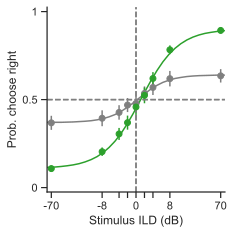

In [94]:
# Probability right
plot_pc_across_batches(experiments=None, kind='prob_right', model='2s_3cov', state_labels=['Disengaged', 'Engaged'], colors=['tab:gray', 'tab:green'], figsize=figsize)
# plt.title('2 states 3 covariates')
plt.title('')
# plt.legend(frameon=False)

In [27]:
# # Probability repeat
# plot_pc_across_batches(experiments=None, kind='prob_rep', model='2s_3cov', state_labels=['Disengaged', 'Engaged'], colors=['tab:gray', 'tab:green'], figsize=figsize)
# plt.title('2 states 3 covariates')
# plt.legend(frameon=False)

Cherry picking for experiment: 2AFC_2
Number of responded trials in data collection (with evidences):
325: 7279 trials
326: 2211 trials
327: 9386 trials
328: 0 trials
329: 11541 trials
330: 4658 trials
331: 0 trials
332: 27879 trials
333: 25533 trials
334: 102 trials
335: 12712 trials
337: 20602 trials


Subjects left behind (never learnt):
328: 0 trials
331: 0 trials
334: 102 trials


Bad subjects (based on lapses): []

Good subjects:
325: 0.32 lapses
326: 0.65 lapses
327: 0.17 lapses
329: 0.34 lapses
330: 0.35 lapses
332: 0.36 lapses
333: 0.14 lapses
335: 0.22 lapses
337: 0.35 lapses


Cherry picking for experiment: 2AFC_3
Number of responded trials in data collection (with evidences):
387: 0 trials
395: 0 trials
398: 0 trials
419: 10403 trials
420: 20117 trials
422: 21061 trials
501: 0 trials
614: 0 trials
615: 0 trials
616: 14090 trials
617: 1728 trials
618: 0 trials
619: 7257 trials
620: 949 trials
623: 13642 trials
625: 0 trials
627: 0 trials


Subjects left behind (never learnt)

Text(0.5, 1.0, '')

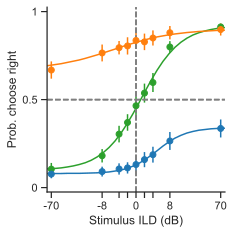

In [95]:
# Probability right
plot_pc_across_batches(experiments=None, kind='prob_right', model='3s_2cov', state_labels=['Engaged', 'BiasedLeft', 'BiasedRight'], colors=['tab:green', 'tab:blue', 'tab:orange'], figsize=figsize)
# plt.title('3 states 2 covariates')
plt.title('')
# plt.legend(frameon=False)

In [29]:
# # Probability repeat
# plot_pc_across_batches(experiments=None, kind='prob_rep', model='3s_2cov', state_labels=['Engaged', 'BiasedLeft', 'BiasedRight'], colors=['tab:green', 'tab:blue', 'tab:orange'], figsize=figsize)
# plt.title('3 states 2 covariates')
# plt.legend(frameon=False)

### Action trace

In [30]:
def plot_pc_at(df, state=None):

    def logistic(x, beta0, beta1):
        return 1 / (1 + np.exp(-(beta0 + beta1 * x)))

    # Compute action trace per session
    df['ActionTrace'] = np.nan
    for session_id, df_session in df.groupby('Session'):
        at_choice, _, _ = get_action_trace(df_session)
        df.loc[df_session.index, 'ActionTrace'] = at_choice
    action_trace = df.ActionTrace

    # Compute quantile-based bin edges
    n_bins = df.ILD.nunique()  # Same as stimulus PC
    bin_edges = np.quantile(action_trace, np.linspace(0, 1, n_bins + 1))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Assign trials to bins
    bin_idx = np.digitize(action_trace, bin_edges, right=True) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    df['BinCenter'] = bin_centers[bin_idx]

    if state is not None:
        df = df[df['StateLabel'] == state]
        if state == 'Engaged':
            color = 'tab:green'
        elif state == 'Disengaged':
            color = 'tab:gray'
    else:
        color = 'k'

    summary = df.groupby(['Subject', 'BinCenter'])['Choice'].mean().groupby('BinCenter').agg(mean='mean', sem='sem').reset_index()
    x = summary['BinCenter']
    y = summary['mean']
    yerr = summary['sem']

    # Fit logistic curve to the binned means
    popt, _ = curve_fit(logistic, x, y, p0=[0, 1])
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = logistic(x_fit, *popt)
    plt.plot(x_fit, y_fit, color=color)

    # plt.figure(figsize=figsize, constrained_layout=True)
    plt.axhline(0.5, color='tab:gray', ls='--')
    plt.axvline(0., color='tab:gray', ls='--')
    plt.errorbar(x, y, yerr=yerr, fmt='o', color=color, label=state)
    plt.ylim([-0.025, 1.025])
    plt.xticks(bin_centers, ('-1', '', '', '', '0', '', '', '', '1'))
    plt.yticks([0, 0.5, 1], [0, 0.5, 1])
    plt.xlabel(r'$A_t$ (norm.)')
    plt.ylabel('Prob. choose right')
    plt.title('2 states 3 covariates')
    plt.ylim(0, 1)
    sns.despine()

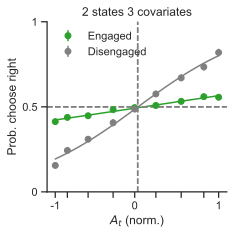

In [31]:
plt.figure(figsize=figsize, constrained_layout=True)
plot_pc_at(df1, state='Engaged')
plot_pc_at(df1, state='Disengaged')
plt.legend(frameon=False)

# Accuracy

## Log-likelihood

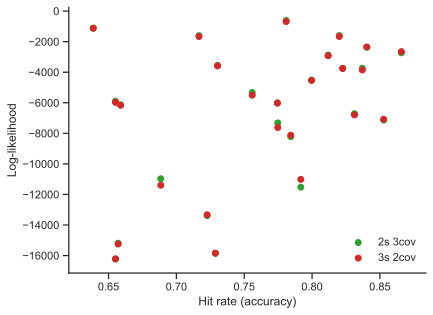

In [32]:
# Compute per-subject averages
hit_rate1 = df1.groupby('Subject')['Hit'].mean()
ll1 = df1.groupby('Subject')['LogLikelihood'].mean()
hit_rate2 = df2.groupby('Subject')['Hit'].mean()
ll2 = df2.groupby('Subject')['LogLikelihood'].mean()

# Plot
plt.figure()
plt.scatter(hit_rate1, ll1, color='tab:green', label='2s 3cov')
plt.scatter(hit_rate2, ll2, color='tab:red', label='3s 2cov')
plt.xlabel('Hit rate (accuracy)')
plt.ylabel('Log-likelihood')
plt.legend()
sns.despine()

## Weights

Kept 20 / 25 subjects after column-wise IQR filtering
Kept 17 / 25 subjects after column-wise IQR filtering
Slope comparison (paired bootstrap)
  Δslope (1 − 2) = -2.0158
  95% CI = [-6.3865, 0.5207]
Corrected bootstrap p ≈ 0.168


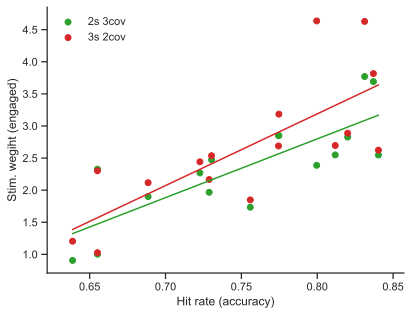

In [33]:
from scipy.stats import linregress

weights_1 = get_weights(df1)
weights_2 = get_weights(df2)
mask_1 = remove_outliers(weights_1)
mask_2 = remove_outliers(weights_2)
paired_mask = mask_1 & mask_2
weights_1 = weights_1[paired_mask]
weights_2 = weights_2[paired_mask]

# Extract stim weight in engaged state
stim_w_1 = weights_1[:, 1, 0]
stim_w_2 = weights_2[:, 0, 0]

hit_rate1 = df1.groupby('Subject')['Hit'].mean()
hit_rate2 = df2.groupby('Subject')['Hit'].mean()
hit_rate1 = hit_rate1[paired_mask]
hit_rate2 = hit_rate2[paired_mask]

# Plot
plt.figure()
plt.scatter(hit_rate1, stim_w_1, color='tab:green', label='2s 3cov')
plt.scatter(hit_rate2, stim_w_2, color='tab:red', label='3s 2cov')
plt.xlabel('Hit rate (accuracy)')
plt.ylabel('Stim. wegiht (engaged)')
plt.legend()
sns.despine()

# Linear fits
slope1, intercept1, r1, p1, _ = linregress(hit_rate1, stim_w_1)
slope2, intercept2, r2, p2, _ = linregress(hit_rate2, stim_w_2)

# X range for plotting
x = np.linspace(min(hit_rate1.min(), hit_rate2.min()), max(hit_rate1.max(), hit_rate2.max()), 100)

plt.plot(x, slope1 * x + intercept1, color='tab:green')
plt.plot(x, slope2 * x + intercept2, color='tab:red')

# Paired bootstrap
rng = np.random.default_rng(42)
n_boot = 1000

delta_slope = []
idx = np.arange(len(hit_rate1))
for _ in range(n_boot):
    boot_idx = rng.choice(idx, size=len(idx), replace=True)
    s1, _, _, _, _ = linregress(
        hit_rate1.values[boot_idx],
        stim_w_1[boot_idx]
    )
    s2, _, _, _, _ = linregress(
        hit_rate2.values[boot_idx],
        stim_w_2[boot_idx]
    )
    delta_slope.append(s1 - s2)
delta_slope = np.array(delta_slope)

# Two-sided p-value: fraction of bootstrap Δslopes that are on the opposite side of 0
ci_low, ci_high = np.percentile(delta_slope, [2.5, 97.5])
observed_delta = slope1 - slope2
p_delta = np.mean(delta_slope * observed_delta <= 0) * 2  # multiply by 2 for two-sided
p_delta = min(p_delta, 1.0)  # cap at 1

print('Slope comparison (paired bootstrap)')
print(f'  Δslope (1 − 2) = {slope1 - slope2:.4f}')
print(f'  95% CI = [{ci_low:.4f}, {ci_high:.4f}]')
print(f'Corrected bootstrap p ≈ {p_delta:.3f}')

## p(engaged)

Slope comparison (paired bootstrap)
  Δslope (1 − 2) = -0.1418
  95% CI = [-0.6880, 0.3811]
  Corrected bootstrap p ≈ 0.586


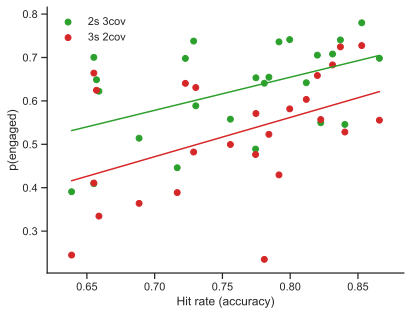

In [34]:
# Compute per-subject averages
hit_rate1 = df1.groupby('Subject')['Hit'].mean()
p_engaged_1 = df1.groupby('Subject')['p1'].mean()
hit_rate2 = df2.groupby('Subject')['Hit'].mean()
p_engaged_2 = df2.groupby('Subject')['p0'].mean()

# Plot
plt.figure()
plt.scatter(hit_rate1, p_engaged_1, color='tab:green', label='2s 3cov')
plt.scatter(hit_rate2, p_engaged_2, color='tab:red', label='3s 2cov')
plt.xlabel('Hit rate (accuracy)')
plt.ylabel('p(engaged)')
plt.legend()
sns.despine()

# Linear fits
slope1, intercept1, r1, p1, _ = linregress(hit_rate1, p_engaged_1)
slope2, intercept2, r2, p2, _ = linregress(hit_rate2, p_engaged_2)

# X range for plotting
x = np.linspace(min(hit_rate1.min(), hit_rate2.min()), max(hit_rate1.max(), hit_rate2.max()), 100)

plt.plot(x, slope1 * x + intercept1, color='tab:green')
plt.plot(x, slope2 * x + intercept2, color='tab:red')

# Paired bootstrap
rng = np.random.default_rng(42)
n_boot = 1000

delta_slope = []
idx = np.arange(len(hit_rate1))

for _ in range(n_boot):
    boot_idx = rng.choice(idx, size=len(idx), replace=True)

    s1, _, _, _, _ = linregress(hit_rate1.values[boot_idx], p_engaged_1.values[boot_idx])
    s2, _, _, _, _ = linregress(hit_rate2.values[boot_idx], p_engaged_2.values[boot_idx])

    delta_slope.append(s1 - s2)

delta_slope = np.array(delta_slope)

# Confidence interval + two-sided p-value
ci_low, ci_high = np.percentile(delta_slope, [2.5, 97.5])
observed_delta = slope1 - slope2
p_delta = np.mean(delta_slope * observed_delta <= 0) * 2
p_delta = min(p_delta, 1.0)

print('Slope comparison (paired bootstrap)')
print(f'  Δslope (1 − 2) = {observed_delta:.4f}')
print(f'  95% CI = [{ci_low:.4f}, {ci_high:.4f}]')
print(f'  Corrected bootstrap p ≈ {p_delta:.3f}')

# Playground
Manually fix weights

In [35]:
# import warnings
# warnings.filterwarnings('ignore')
# import os
# import pandas as pd
# import numpy as np
# import numpy.random as npr
# import matplotlib.pyplot as plt
# import seaborn as sns
# import ssm
# from scipy.special import expit as logistic
# from matplotlib.lines import Line2D
#
# from glmhmm import *
#
# # Plotting style
# default_figsize = np.array(plt.rcParams['figure.figsize'])
# # sns.set_theme()
# sns.set_style('ticks')
# sns.set_context('poster')
# style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
# plt.style.use(style_path)
# %config InlineBackend.figure_format = 'retina'
#
# # Set the parameters of the GLM-HMM
# n_states = 2        # Number of discrete states (from Ashwood et al. 2020)
# obs_dim = 1         # Number of observed dimensions (1 for binary choice)
# n_categories = 2    # Number of categories for output (2 for binary choice)
# input_dim = 2       # Input dimensions (stimulus and bias)
#
# glmhmm = ssm.HMM(n_states, obs_dim, input_dim, observations='input_driven_obs',
#                    observation_kwargs=dict(C=n_categories), transitions='standard')
#
# # Load data from example mouse
# try:
#     df = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_2\333.csv')  # Ephys PC
# except FileNotFoundError:
#     df = pd.read_csv('/home/alexis/PycharmProjects/glue_sessions/2AFC_2/333.csv')  # Cluster
#
# # Filters for groups 1-3
# df = df[df.Stage == 4].reset_index(drop=True)
# df = df[df.Motor == 4].reset_index(drop=True)
# # df = df[df.StimDur == 1].reset_index(drop=True)
# df = df[df.P > 0].reset_index(drop=True)
#
# # Drop misses (Choice == NaN)
# df = df.dropna(subset=['Choice']).reset_index(drop=True)
#
# covariates = ['stim_vals', 'bias']
# state_label_map = {0: 'Lapse', 1: 'Engaged'}
#
# inputs, choices = parse_glmhmm(df, covariates=covariates)
#
# # Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
# method = 'em'  # Expectation Maximization method
# num_iters = 200 # Max number of EM iterations
# tolerance = 1e-4  # Tolerance for stopping criterion
# # fit_ll = glmhmm.fit(choices, inputs=inputs, method=method, num_iters=num_iters, tolerance=tolerance)
#
# def enforce_lapse_constraint(hmm, lapse_state=1, stim_index=0):
#     hmm.observations.params[lapse_state, 0, stim_index] = 0.0
#
# N_iters = 200
# lls = []
#
# # from tqdm import trange
# # pbar = trange(N_iters, desc='Fitting lapse GLM-HMM')
#
# for _ in range(N_iters):
#     ll = glmhmm.fit(
#         choices,
#         inputs=inputs,
#         method='em',
#         num_iters=1,
#         initialize=(_ == 0)
#     )
#     print(f'EM Iteration {_+1}: Log Likelihood = {ll[-1]}')
#     # ll = glmhmm.em_step(choices, inputs=inputs)  # Not implemented?
#     enforce_lapse_constraint(glmhmm)
#     lls.append(ll[-1])
#     if _ > 1 and abs(lls[-1] - lls[-2]) < tolerance:
#         break
#
# ll = glmhmm.log_likelihood(choices, inputs=inputs)
# n_trials = len(df)
# ll = ll / n_trials
# ll = ll / np.log(2)
# ll_lapse = ll
# print(ll_lapse)
#
# plt.plot(lls, marker='o')
# plt.xticks(np.arange(5), ['1','2','3','4','5'])
#
# plt.plot(lls, marker='o')
# plt.xticks(np.arange(6), ['1', 'L', '2','3','4','5'])
# plt.xlabel('N states')
# plt.ylabel('Mean LL per trial (bits)')
# plt.title('Model comparison')
# sns.despine()

# Save all notebook's figures

In [155]:
# Whole notebook outputs (no input or prompt, only Markdown and figures)
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt  # As HTML
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt  # As PDF

# Export all figures
save_notebook_files(notebook_path='notebook_model_comparison.ipynb')

Saved 24 images to notebook_model_comparison_files/
